Import all libraries needed for this project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import joblib

# Import Data

In [2]:
df = pd.read_csv(r"C:\Users\User\flood_risk_classifier\data\raw_flood_data.csv")

Import the raw dataset into the notebook using "read_csv" and save the data as df

In [3]:
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


Check for the overview of the data by ovserving the headings of the table

In [4]:
df.shape

(2963, 17)

Checking for the shape of the dataset
The data consist of 2963 rows and 17 columns

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   str    
 1   city_name                            2963 non-null   str    
 2   admin_ward                           2963 non-null   str    
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   str    
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   str    
 8   land_use                             2963 non-null   str    
 9   soil_group                           2601 non-null   str    
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m              2724

# Checking for the dataframe in the dataset
1. 10 columns consist of string
2. 6 columns consist of float
3. 1 column consist of only integer

In [6]:
df.describe()

,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years
count,2963.000000,2963.000000,2802.000000,2679.000000,2724.000000,2963.000000,2963.000000
mean,19.399103,31.676123,37.689818,6.290866,123.202203,43.811441,19.730003
std,24.446320,79.542482,38.708958,2.187365,107.764541,25.221200,25.182883
min,-36.999038,-123.292949,-3.000000,1.270000,0.200000,5.400000,2.000000
25%,6.580006,-43.124581,8.725000,4.670000,47.975000,25.800000,5.000000
50%,23.760802,36.889173,25.130000,6.250000,91.700000,37.900000,10.000000
75%,37.887422,101.701136,59.620000,7.830000,162.625000,55.550000,25.000000
max,55.821219,174.911271,266.700000,12.070000,751.700000,150.000000,100.000000


In [7]:
df.isnull().sum()

segment_id                               0
city_name                                0
admin_ward                               0
latitude                                 0
longitude                                0
catchment_id                             0
elevation_m                            161
dem_source                               0
land_use                                 0
soil_group                             362
drainage_density_km_per_km2            284
storm_drain_proximity_m                239
storm_drain_type                       178
rainfall_source                        315
historical_rainfall_intensity_mm_hr      0
return_period_years                      0
risk_labels                              0
dtype: int64

Checking for missing values:
6 columns has missing values while the rest do not as shown in the cell above

# Checking for value counts in Columns

In [8]:
df["risk_labels"].value_counts()

risk_labels
monitor                                                            1991
low_lying                                                           386
extreme_rain_history                                                137
sparse_drainage                                                      88
ponding_hotspot|low_lying                                            78
                                                                   ... 
ponding_hotspot|extreme_rain_history|event_2023-11-12                 1
low_lying|event_2025-05-06                                            1
ponding_hotspot|extreme_rain_history|low_lying|event_2025-06-09       1
ponding_hotspot|extreme_rain_history|event_2023-07-03                 1
extreme_rain_history|low_lying|event_2023-11-07                       1
Name: count, Length: 195, dtype: int64

1. This is the target column in the raw data
2. The column has a lot of variables which will not be good for the model

In [9]:
df["storm_drain_type"].value_counts()

storm_drain_type
CurbInlet      843
Manhole        749
GratedInlet    644
OpenChannel    549
Name: count, dtype: int64

1. The value counts for each of the variable in the column
2. This column is about the type of drainage in the area

In [10]:
df["land_use"].value_counts()

land_use
Residential      827
Roads            599
Commercial       493
Green            359
Industrial       357
Mixed            110
Institutional    106
Water             83
Informal          29
Name: count, dtype: int64

1. The value counts for the land_use column
2. This column is about the use of that land that is being considered; either residential, commercial and so on

In [11]:
df["soil_group"].value_counts()

soil_group
B    747
C    713
D    594
A    547
Name: count, dtype: int64

1. The value count for the type of soil being considered.
2. Group A refers to soil with high infilteration ability
3. Group B refers to soil with moderate infilteration
4. Group C refers to soil with relatively low infilteration
5. Group D refers to soil with very low infilteration ability

In [12]:
df["storm_drain_type"].value_counts()

storm_drain_type
CurbInlet      843
Manhole        749
GratedInlet    644
OpenChannel    549
Name: count, dtype: int64

In [13]:
df["return_period_years"].max()

np.int64(100)

### Observations

1. Datasets consist of 2963 rows and 17 columns
2. 7 columns numerical because they are float and integer; float64(6), int64(1)
3. 10 columns are categorical because they are made of string; str(10)
4. 6 columns have missing values (elevation_m, soil_group, drainage_density_km_per_km2, storm_drain_proximity_m, storm_drain_type, rainfall_source)
5. The distribution of the target column, risk_labels is not balanced because one of the elements have much more data than the rest making it imbalanced.

# EXPLORATORY DATA ANALYSIS (EDA)

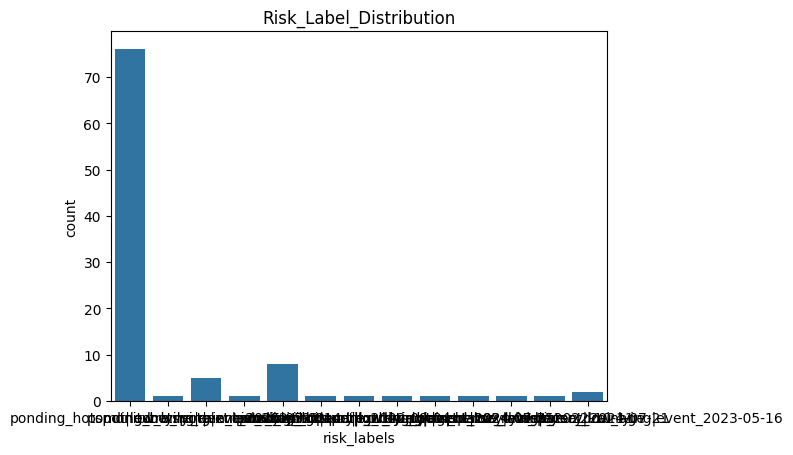

In [14]:
# Distribution of target (Top 100 columns)

sns.countplot(x="risk_labels", data=df.head(100))
plt.title("Risk_Label_Distribution")
plt.show()

1. The chart above the representation of target variable "risk_labels"
2. This shows that the column has a lot of distinct categoriesand are not evenly distributed
3. As such there is need to simplify this category.

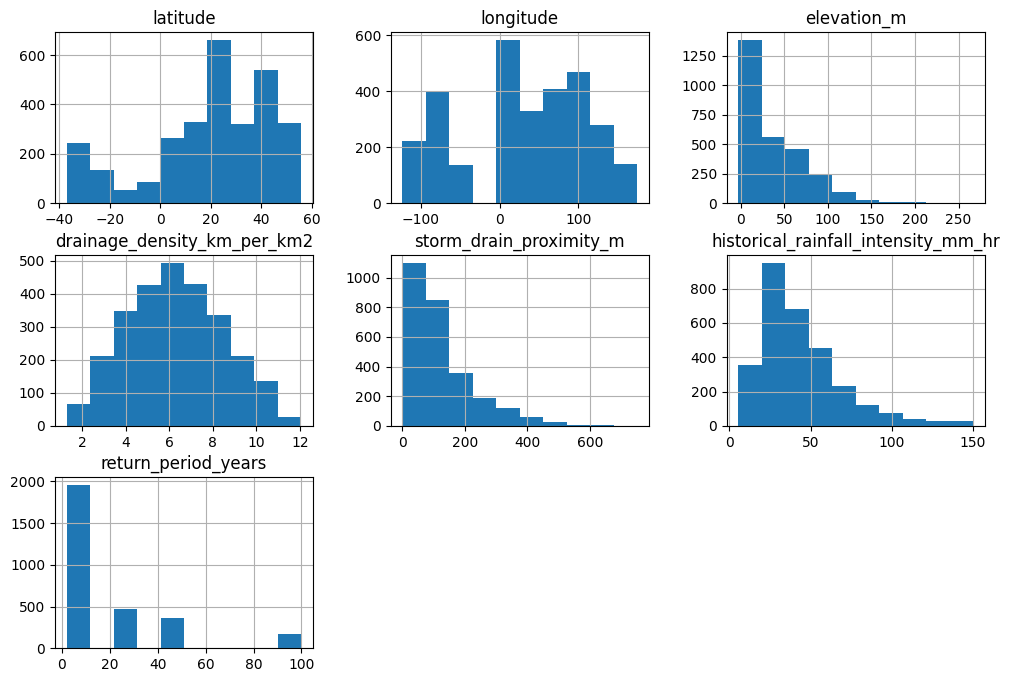

In [15]:
# Numeric Feature Distribution

df.hist(figsize=(12,8))
plt.show()

1. These charts are for numerical values
2. The latitude and longitude columns cosist of both positive and negative values.
3. The elevation column also consist of negative values which represent locations that are below sea levels and lower elevations are more concentrated
4. The drainage density is bell shaped with highest concentration appearing around 6km/km2. This column describes the length of drainage channel relative to area of  region.
5. The storm draim proximity has a clear right skewed distribution. This is important for this model because locations farther from effective storm drain will experience difficulty in removing surface water.
6. The historical rainfall intensity also have a right skewed distribution. This is a reasonable pattern for rainfall data as extreme high rainfall events tend to occur less frequently than moderate ones. this predictor is important because intense rainfall may exceed drainage systems and contribute to flooding
7. The return period (years) column is concentrated at low values. This shows that the data may contain observations associated with relatively short return periods. This column shows the statistical average intarval associated with an event of a particular magnitude

<Axes: >

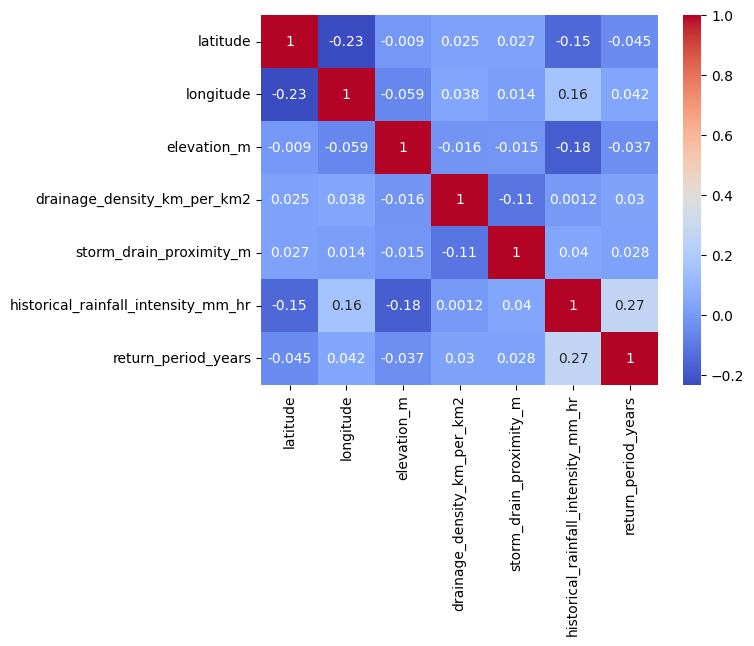

In [16]:
# Correlation Heatmap (Numeric Columns only)

sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")

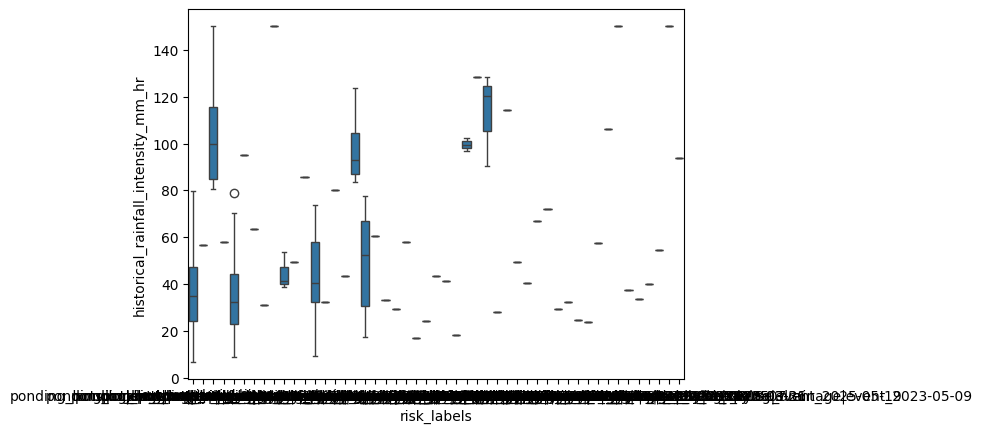

In [17]:
# Feature vs Target (Top 500 columns)

sns.boxplot(x="risk_labels", y="historical_rainfall_intensity_mm_hr", data=df.head(500))
plt.show()

# High risk areas often have higher historical rainfall intensity

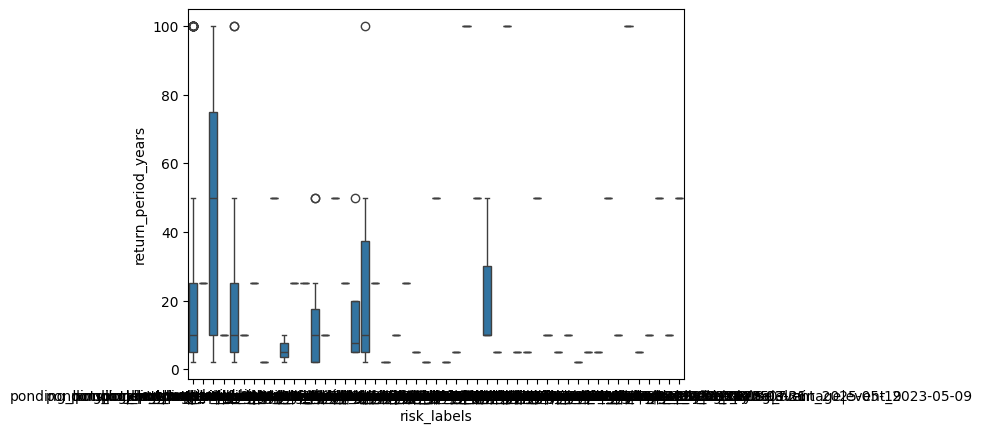

In [18]:
# Risk_Labels against return period years

sns.boxplot(x="risk_labels", y="return_period_years", data=df.head(500))
plt.show()

# The longer the return period years, the higher the risks

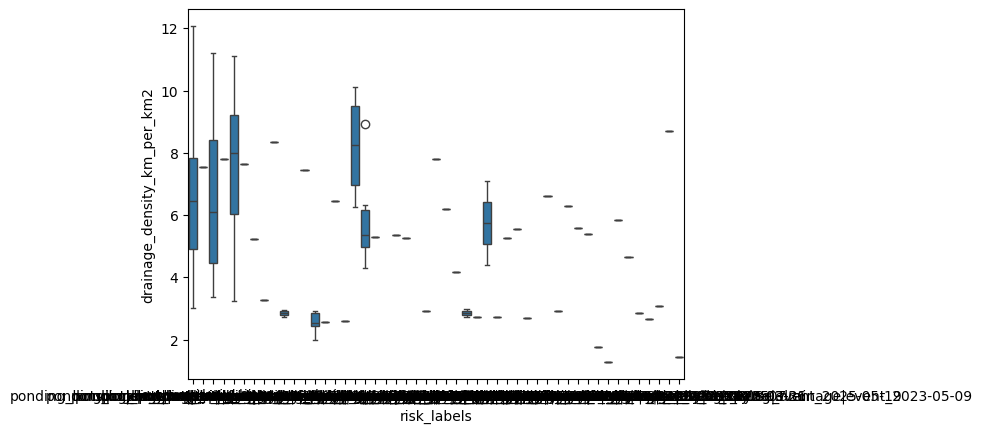

In [19]:
# Risk labels against drainage density

sns.boxplot(x="risk_labels", y="drainage_density_km_per_km2", data=df.head(500))
plt.show()

# Poor drainage lead to higher risk label

# DATA CLEANING

In [20]:
df=df.copy()

In [21]:
# Missing Values
df["elevation_m"]=df["elevation_m"].fillna(df["elevation_m"].median())

In [22]:
# Missing Values
df["soil_group"]=df["soil_group"].fillna(df["soil_group"].mode()[0])

In [23]:
# Missing Values
df["drainage_density_km_per_km2"]=df["drainage_density_km_per_km2"].fillna(df["drainage_density_km_per_km2"].median())

In [24]:
# Missing Values
df["storm_drain_proximity_m"]=df["storm_drain_proximity_m"].fillna(df["storm_drain_proximity_m"].median())

In [25]:
# Missing Values
df["storm_drain_type"]=df["storm_drain_type"].fillna(df["storm_drain_type"].mode()[0])

In [26]:
# Missing Values
df["rainfall_source"]=df["rainfall_source"].fillna(df["rainfall_source"].mode()[0])

In [27]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [28]:
duplicates = df[df.duplicated()]
duplicates

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels


Fill in all missing values in the data

In [29]:
df["risk_labels"].value_counts()

risk_labels
monitor                                                            1991
low_lying                                                           386
extreme_rain_history                                                137
sparse_drainage                                                      88
ponding_hotspot|low_lying                                            78
                                                                   ... 
ponding_hotspot|extreme_rain_history|event_2023-11-12                 1
low_lying|event_2025-05-06                                            1
ponding_hotspot|extreme_rain_history|low_lying|event_2025-06-09       1
ponding_hotspot|extreme_rain_history|event_2023-07-03                 1
extreme_rain_history|low_lying|event_2023-11-07                       1
Name: count, Length: 195, dtype: int64

## Fix target columns imbalance
1. I"ll be simplifying my target column df["risk_labels"] because of imbalance in its components.
2. This action will be done under feature engineering and the column will be named simplified_risks

1. For columns that are numeric, I made use of the median fill in place formula
2. For columns that are srting/category, I made use of the mode fill in place formula
3. There was no duplicated columns

In [30]:
## Clean Datasets

df.to_csv("../data/cleaned_flood_data.csv", index=False)

Save the data without overwriting the original raw data file

In [31]:
df.isnull().sum()

segment_id                             0
city_name                              0
admin_ward                             0
latitude                               0
longitude                              0
catchment_id                           0
elevation_m                            0
dem_source                             0
land_use                               0
soil_group                             0
drainage_density_km_per_km2            0
storm_drain_proximity_m                0
storm_drain_type                       0
rainfall_source                        0
historical_rainfall_intensity_mm_hr    0
return_period_years                    0
risk_labels                            0
dtype: int64

All the columns without no missing value

# FEATURE ENGINEERING

In [32]:
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,B,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,91.7,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


In [33]:
df

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,B,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,91.7,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,6.25,78.8,GratedInlet,ERA5,46.5,10,monitor
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,6.25,236.1,GratedInlet,ERA5,27.7,2,monitor
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying


In [34]:
df.shape

(2963, 17)

In [35]:
df.isnull().sum()

segment_id                             0
city_name                              0
admin_ward                             0
latitude                               0
longitude                              0
catchment_id                           0
elevation_m                            0
dem_source                             0
land_use                               0
soil_group                             0
drainage_density_km_per_km2            0
storm_drain_proximity_m                0
storm_drain_type                       0
rainfall_source                        0
historical_rainfall_intensity_mm_hr    0
return_period_years                    0
risk_labels                            0
dtype: int64

In [36]:
df["drainage_density_km_per_km2"]/(df["storm_drain_proximity_m"]+1)

df["drainage_efficiency"]=df["drainage_density_km_per_km2"]/(df["storm_drain_proximity_m"]+1)


1. This feature is imprtant in determining the flood risk labels. It is achieved from the formula above.
2. The higher this value shows that the drainage is efficient and working well reducing flood risks

In [37]:
df["drainage_efficiency"].min()

np.float64(0.003345543345543346)

In [38]:
df["historical_rainfall_intensity_mm_hr"]/(df["return_period_years"])

df["rainfall_per_return_period"]=df["historical_rainfall_intensity_mm_hr"]/(df["return_period_years"])

1. This feature is also important in determing the flood risks of this model. It is achieved from the formula above.
2. The higher this value is shows a greater intensity in relative to frequency

In [39]:
df["rainfall_per_return_period"].min()

np.float64(0.106)

In [40]:
df["risk_labels"].value_counts()

risk_labels
monitor                                                            1991
low_lying                                                           386
extreme_rain_history                                                137
sparse_drainage                                                      88
ponding_hotspot|low_lying                                            78
                                                                   ... 
ponding_hotspot|extreme_rain_history|event_2023-11-12                 1
low_lying|event_2025-05-06                                            1
ponding_hotspot|extreme_rain_history|low_lying|event_2025-06-09       1
ponding_hotspot|extreme_rain_history|event_2023-07-03                 1
extreme_rain_history|low_lying|event_2023-11-07                       1
Name: count, Length: 195, dtype: int64

In [41]:
# Simplified target column

def simplify_risks(label):
    label = label.lower()
    
    if ("extreme_rain_history" in label) or ("ponding_hotspot" in label):
        return "High Risk"
    elif ("low_lying" in label) or ("sparse_drainage" in label):
        return "Medium Risk"
    elif "monitor" in label:
        return "Low Risk"
    else:
        return None

1. Engineer a new feature called simplify_risks
2. This will simplify all those variables into just 3 categories
3. This will make the model easy to make predictions

In [42]:
df["simplified_risks"]=df["risk_labels"].apply(simplify_risks)

In [43]:
df["simplified_risks"].value_counts()

simplified_risks
Low Risk       1994
Medium Risk     574
High Risk       395
Name: count, dtype: int64

In [44]:
df["simplified_risks"].unique()

<ArrowStringArray>
['Low Risk', 'High Risk', 'Medium Risk']
Length: 3, dtype: str

In [45]:
## Engineered Datasets

df.to_csv("../data/engineered_flood_data.csv", index=False)

Save the new engineered features data without overwriting the initial data

In [46]:
df

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels,drainage_efficiency,rainfall_per_return_period,simplified_risks
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,B,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor,0.026440,0.788,Low Risk
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,91.7,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02,0.081338,2.272,High Risk
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor,0.071661,3.260,Low Risk
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor,0.192632,7.700,Low Risk
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor,0.015337,4.160,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,6.25,78.8,GratedInlet,ERA5,46.5,10,monitor,0.078321,4.650,Low Risk
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26,0.938983,14.120,High Risk
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,6.25,236.1,GratedInlet,ERA5,27.7,2,monitor,0.026360,13.850,Low Risk
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying,0.029547,1.316,High Risk


In [47]:
df["risk_labels"]

0                                          monitor
1       ponding_hotspot|low_lying|event_2025-05-02
2                                          monitor
3                                          monitor
4                                          monitor
                           ...                    
2958                                       monitor
2959    ponding_hotspot|low_lying|event_2024-07-26
2960                                       monitor
2961                extreme_rain_history|low_lying
2962                                       monitor
Name: risk_labels, Length: 2963, dtype: str

In [48]:
df["simplified_risks"]

0        Low Risk
1       High Risk
2        Low Risk
3        Low Risk
4        Low Risk
          ...    
2958     Low Risk
2959    High Risk
2960     Low Risk
2961    High Risk
2962     Low Risk
Name: simplified_risks, Length: 2963, dtype: str

In [49]:
# Drop irrelevant columns
df = df.copy()

In [50]:
df = df.drop(columns=["segment_id", "admin_ward", "catchment_id", "dem_source", "risk_labels", "rainfall_source"])

Drop columns that will not affect the outcome of the prediction

In [51]:
df

,city_name,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,drainage_efficiency,rainfall_per_return_period,simplified_risks
0,"Colombo, Sri Lanka",6.920633,79.912600,25.13,Institutional,B,4.27,160.5,CurbInlet,39.4,50,0.026440,0.788,Low Risk
1,"Chennai, India",13.076487,80.281774,-2.19,Residential,D,7.54,91.7,OpenChannel,56.8,25,0.081338,2.272,High Risk
2,"Ahmedabad, India",23.019473,72.638578,30.88,Industrial,B,11.00,152.5,OpenChannel,16.3,5,0.071661,3.260,Low Risk
3,"Hong Kong, China",22.302602,114.078673,24.28,Residential,B,7.32,37.0,Manhole,77.0,10,0.192632,7.700,Low Risk
4,"Durban, South Africa",-29.887602,30.911008,35.70,Industrial,C,4.50,292.4,OpenChannel,20.8,5,0.015337,4.160,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,"Paris, France",48.872870,2.246250,30.46,Residential,C,6.25,78.8,GratedInlet,46.5,10,0.078321,4.650,Low Risk
2959,"Shanghai, China",31.195529,121.435540,-3.00,Industrial,C,5.54,4.9,OpenChannel,70.6,5,0.938983,14.120,High Risk
2960,"Vancouver, Canada",49.162783,-123.037084,14.16,Green,B,6.25,236.1,GratedInlet,27.7,2,0.026360,13.850,Low Risk
2961,"Lagos, Nigeria",6.504570,3.388571,7.00,Industrial,B,8.74,294.8,OpenChannel,131.6,100,0.029547,1.316,High Risk


In [52]:
## Final Flood Datasets

df.to_csv("../data/final_flood_data.csv", index=False)

Saving the final dataset that will be used to test and train my model

In [53]:
df.isnull().sum()

city_name                              0
latitude                               0
longitude                              0
elevation_m                            0
land_use                               0
soil_group                             0
drainage_density_km_per_km2            0
storm_drain_proximity_m                0
storm_drain_type                       0
historical_rainfall_intensity_mm_hr    0
return_period_years                    0
drainage_efficiency                    0
rainfall_per_return_period             0
simplified_risks                       0
dtype: int64

In [54]:
df["drainage_efficiency"].max()

np.float64(8.425)

In [55]:
# Separate features and targets into x and y
x = df.drop(columns=["simplified_risks"])
y = df["simplified_risks"]

1. For x values, all columns aside the simplified_risks column
2. for y values, the simplified _risks column

In [56]:
x

,city_name,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,drainage_efficiency,rainfall_per_return_period
0,"Colombo, Sri Lanka",6.920633,79.912600,25.13,Institutional,B,4.27,160.5,CurbInlet,39.4,50,0.026440,0.788
1,"Chennai, India",13.076487,80.281774,-2.19,Residential,D,7.54,91.7,OpenChannel,56.8,25,0.081338,2.272
2,"Ahmedabad, India",23.019473,72.638578,30.88,Industrial,B,11.00,152.5,OpenChannel,16.3,5,0.071661,3.260
3,"Hong Kong, China",22.302602,114.078673,24.28,Residential,B,7.32,37.0,Manhole,77.0,10,0.192632,7.700
4,"Durban, South Africa",-29.887602,30.911008,35.70,Industrial,C,4.50,292.4,OpenChannel,20.8,5,0.015337,4.160
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,"Paris, France",48.872870,2.246250,30.46,Residential,C,6.25,78.8,GratedInlet,46.5,10,0.078321,4.650
2959,"Shanghai, China",31.195529,121.435540,-3.00,Industrial,C,5.54,4.9,OpenChannel,70.6,5,0.938983,14.120
2960,"Vancouver, Canada",49.162783,-123.037084,14.16,Green,B,6.25,236.1,GratedInlet,27.7,2,0.026360,13.850
2961,"Lagos, Nigeria",6.504570,3.388571,7.00,Industrial,B,8.74,294.8,OpenChannel,131.6,100,0.029547,1.316


In [57]:
y

0        Low Risk
1       High Risk
2        Low Risk
3        Low Risk
4        Low Risk
          ...    
2958     Low Risk
2959    High Risk
2960     Low Risk
2961    High Risk
2962     Low Risk
Name: simplified_risks, Length: 2963, dtype: str

In [58]:
# Identify column types into cat and num columns
cat_cols = x.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = x.select_dtypes(include="number").columns.tolist()

Identifying the numerical and categorical columns

In [59]:
cat_cols

['city_name', 'land_use', 'soil_group', 'storm_drain_type']

In [60]:
num_cols

['latitude',
 'longitude',
 'elevation_m',
 'drainage_density_km_per_km2',
 'storm_drain_proximity_m',
 'historical_rainfall_intensity_mm_hr',
 'return_period_years',
 'drainage_efficiency',
 'rainfall_per_return_period']

In [61]:
# Train_Test Split

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Splitting the data into x and y train and test data

In [63]:
x_train

,city_name,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,drainage_efficiency,rainfall_per_return_period
518,"Manila, Philippines",14.580626,120.972563,12.81,Roads,C,7.21,116.0,Manhole,45.6,5,0.061624,9.120
2778,"Manila, Philippines",14.483235,120.886102,12.69,Green,B,1.39,65.2,Manhole,53.3,10,0.020997,5.330
573,"Colombo, Sri Lanka",6.916385,79.909313,13.54,Residential,B,8.03,91.7,Manhole,42.0,25,0.086624,1.680
2810,"Hong Kong, China",22.501791,114.315287,8.87,Commercial,C,8.25,179.9,GratedInlet,63.5,25,0.045605,2.540
2390,"Dubai, UAE",25.180777,55.367484,25.13,Residential,A,8.17,247.5,CurbInlet,13.1,10,0.032877,1.310
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,"Osaka, Japan",34.503467,135.566862,97.81,Commercial,D,10.51,91.7,OpenChannel,29.6,10,0.113376,2.960
1095,"Miami, USA",25.772128,-80.233645,5.22,Green,B,6.20,83.6,CurbInlet,55.6,25,0.073286,2.224
1130,"Sao Paulo, Brazil",-23.584633,-46.570090,102.05,Commercial,D,8.25,15.4,CurbInlet,34.5,2,0.503049,17.250
1294,"Kuala Lumpur, Malaysia",3.173110,101.681728,89.12,Green,A,5.10,52.3,GratedInlet,69.6,50,0.095685,1.392


In [64]:
x_test

,city_name,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,drainage_efficiency,rainfall_per_return_period
2206,"Lagos, Nigeria",6.452143,3.451479,10.75,Commercial,D,4.20,88.8,CurbInlet,150.0,25,0.046771,6.000
1313,"Rotterdam, Netherlands",51.972605,4.583407,16.16,Industrial,A,5.75,91.7,CurbInlet,25.9,2,0.062028,12.950
767,"New York, USA",40.757452,-74.069899,6.05,Institutional,C,3.22,187.4,OpenChannel,32.4,5,0.017091,6.480
1461,"Tokyo, Japan",35.708829,139.649493,22.08,Industrial,C,6.82,445.0,CurbInlet,28.4,2,0.015291,14.200
2689,"Buenos Aires, Argentina",-34.672110,-58.323738,-3.00,Informal,B,4.41,85.8,Manhole,14.4,5,0.050806,2.880
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,"Sao Paulo, Brazil",-23.490872,-46.688000,90.88,Water,D,6.55,145.5,CurbInlet,45.7,50,0.044710,0.914
927,"Houston, USA",29.843230,-95.346401,47.80,Residential,B,6.11,21.4,CurbInlet,46.6,5,0.272768,9.320
2344,"Manila, Philippines",14.537242,121.007069,10.81,Green,B,4.85,239.5,Manhole,128.1,10,0.020166,12.810
1064,"Buenos Aires, Argentina",-34.612000,-58.279973,45.72,Residential,B,6.95,76.0,Manhole,35.1,5,0.090260,7.020


In [65]:
y_train

518        Low Risk
2778    Medium Risk
573        Low Risk
2810       Low Risk
2390       Low Risk
           ...     
1638       Low Risk
1095    Medium Risk
1130       Low Risk
1294       Low Risk
860        Low Risk
Name: simplified_risks, Length: 2370, dtype: str

In [66]:
y_test

2206      High Risk
1313       Low Risk
767     Medium Risk
1461       Low Risk
2689    Medium Risk
           ...     
509        Low Risk
927        Low Risk
2344      High Risk
1064       Low Risk
2608       Low Risk
Name: simplified_risks, Length: 593, dtype: str

# RANDOM FOREST MODEL

Building a Preprocessing and Model Pipeline

In [67]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

In [68]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Preprocessing making use of standard scaler and one hot encoder

In [69]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [70]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [71]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [72]:
# Model Evaluation

In [73]:
y_pred = model.predict(x_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9713322091062394
              precision    recall  f1-score   support

   High Risk       0.94      0.84      0.89        81
    Low Risk       1.00      1.00      1.00       394
 Medium Risk       0.90      0.97      0.93       118

    accuracy                           0.97       593
   macro avg       0.95      0.94      0.94       593
weighted avg       0.97      0.97      0.97       593



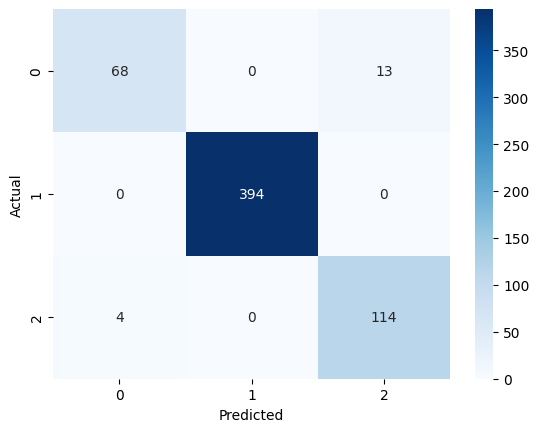

In [75]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest: Evaluating the model to get f1 score macro avg of 0.94

# LOGISTIC REGRESSION MODEL

In [76]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [77]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [78]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [79]:
# l_reg_Model Evaluation

In [80]:
y_pred = model.predict(x_test)

In [81]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8026981450252951
              precision    recall  f1-score   support

   High Risk       0.79      0.73      0.76        81
    Low Risk       0.84      0.92      0.88       394
 Medium Risk       0.64      0.47      0.55       118

    accuracy                           0.80       593
   macro avg       0.76      0.71      0.73       593
weighted avg       0.79      0.80      0.79       593



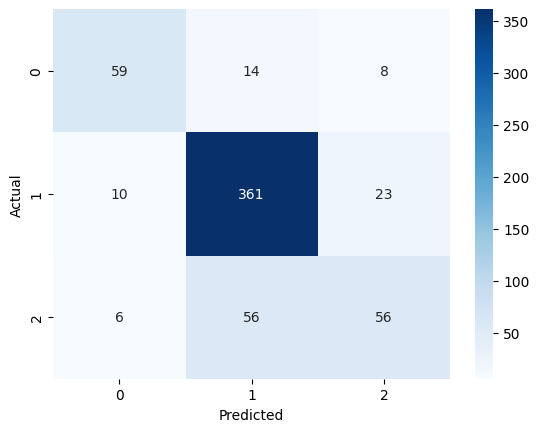

In [82]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression: Evaluating the model to get f1 score macro avg of 0.73

# GRADIENT BOOSTING CLASSIFIER MODEL

In [83]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

In [84]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [85]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [86]:
# gb_Model Evaluation

In [87]:
y_pred = model.predict(x_test)

In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9831365935919055
              precision    recall  f1-score   support

   High Risk       0.96      0.93      0.94        81
    Low Risk       1.00      1.00      1.00       394
 Medium Risk       0.94      0.97      0.96       118

    accuracy                           0.98       593
   macro avg       0.97      0.97      0.97       593
weighted avg       0.98      0.98      0.98       593



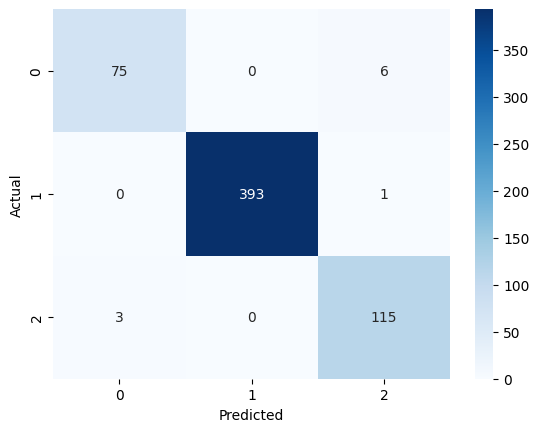

In [89]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Gradient Boosting: Evaluating the model to get f1 score macro avg of 0.97

Gradient Boosting Model is the best performing model of the 3 Models

In [90]:
# Comparison Table for Best Model

In [91]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20]
}

In [92]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="f1_macro")

In [93]:
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [94]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [95]:
best_model = grid_search.best_estimator_

In [96]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [97]:
# Pickle/Save Final Model

In [98]:
joblib.dump(best_model, "../models/flood_risk_model.pkl")

['../models/flood_risk_model.pkl']

In [99]:
joblib.dump(list(x.columns), "../models/model_features.pkl")

['../models/model_features.pkl']

In [100]:
joblib.load("../models/flood_risk_model.pkl")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [101]:
loaded_model = joblib.load("../models/flood_risk_model.pkl")

In [102]:
loaded_model.predict(x_test.iloc[:5])

array(['High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Medium Risk'],
      dtype=object)

The grid_search help to pick the best model

Then I saved the flood_risk_classifier model and model_features as both pkl files and load them into pkl